# Loading datasets with `xnns`: the data hub & `load_dataset()`

`xnns.common.data.hub` gives you a **HuggingFace `load_dataset()`-style one-liner**
for pulling standard atomistic benchmark datasets into `xnns`. One call
**downloads** the raw files (cached and MD5-verified), **preprocesses** them into
`xnns`' native structure dicts, and, optionally, hands you a ready-to-train
`AtomicDataset`.

```python
from xnns.common.data import load_dataset
train = load_dataset("rmd17", molecule="aspirin", split="train", cutoff=5.0)
```

This notebook walks through:

1. Discovering the available datasets
2. The one-liner and what it returns
3. Where files are cached
4. The options: splits, folds, units, subsetting
5. A quick look at the data (EDA + a 3-D render)
6. Going from structure dicts to a training `DataLoader`
7. A second built-in dataset: molecular dimers (`lode_dimers`)
8. Registering **your own** dataset with the hub

The running example is **rMD17** (revised MD17): ten small molecules with
PBE/def2-SVP energies and forces, and five official 1000-structure train/test
splits. Section 7 switches to a very different dataset: biomolecular dimers.

## 0. Setup

`float64` so downstream neighbour-list / graph tensors are double precision, and
we silence the expected `torch.load` `FutureWarning` from `e3nn`.

In [1]:
import warnings

import numpy as np
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
torch.set_default_dtype(torch.float64)

from xnns.common.data import load_dataset, list_datasets

## 1. What datasets are available?

Builders register themselves under a short name; `list_datasets()` enumerates
them. (Section 8 shows how to add your own.)

In [2]:
list_datasets()

['ani1', 'argon_md', 'lode_dimers', 'rmd17']

## 2. The one-liner

Call `load_dataset(name, ...)`. With no `split` argument you get **all splits**
as a mapping: for rMD17 that's `{"train", "test"}` (fold 1 by default), each a
plain list of *structure dicts*.

rMD17 requires a `molecule` argument. Below we pull **every** molecule into a
dict keyed by name; the first call for each downloads and caches it
(per-molecule files are 60–175 MB, ~1.1 GB for all ten). To grab just one, pass
a single `molecule=`.

In [3]:
# the molecule can be one of the following: ethanol, azobenzene, toluene, aspirin, benzene, naphthalene, malonaldehyde, paracetamol, salicylic_acid, uracil
lists = ["ethanol", "azobenzene", "toluene", "aspirin", "benzene", "naphthalene", "malonaldehyde", "paracetamol", "salicylic_acid", "uracil"]
splits = {k: load_dataset("rmd17", molecule=k) for k in lists}

rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:azobenzene train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:azobenzene test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:toluene train:   0%|          | 0/1000 [00:00<?, ? struct/s]

...

rmd17:paracetamol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:salicylic train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:salicylic test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:uracil train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:uracil test:   0%|          | 0/1000 [00:00<?, ? struct/s]

In [4]:
len(splits["aspirin"]["train"])

1000

### Anatomy of a structure dict

Each entry is the plain-dict format the rest of `xnns` consumes
(`structure_to_graph`, `AtomicDataset`): positions in Å, integer atomic numbers,
and- when the dataset provides them- `energy` (eV) and `forces` (eV/Å). rMD17
is **molecular**, so there is no `cell`/`pbc`.

In [5]:
eth = splits["ethanol"]
s = eth["train"][0]
print("keys:        ", sorted(s))
print("atomic_numbers:", s["atomic_numbers"])
print("n_atoms:     ", len(s["atomic_numbers"]))
print("pos shape:   ", s["pos"].shape)
print("forces shape:", s["forces"].shape)
print("energy [eV]: ", s["energy"])

keys:         ['atomic_numbers', 'energy', 'forces', 'pos']
atomic_numbers: [6 6 8 1 1 1 1 1 1]
n_atoms:      9
pos shape:    (9, 3)
forces shape: (9, 3)
energy [eV]:  -4209.784941392146


### Caching

The download is verified by MD5 and reused, so a second load is essentially free
and works offline.

In [6]:
import time

t = time.perf_counter()
_ = load_dataset("rmd17", molecule="ethanol")
print(f"cached reload: {time.perf_counter() - t:.3f} s")

rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

cached reload: 0.174 s


## 3. Where does the data live?

By default everything caches under the repository's `datasets/` directory, one
subfolder per dataset (`datasets/rmd17/raw/`). Override it per call with
`cache_dir=...`, or globally with the `XNNS_DATASETS` (or `XNNS_CACHE`)
environment variable.

In [7]:
from xnns.common.data.hub import default_cache_dir

raw = default_cache_dir() / "rmd17" / "raw"
print("cache root:", default_cache_dir())
print()
for p in sorted(raw.glob("*ethanol*")) + sorted(raw.glob("*.csv")):
    print(f"  {p.name:28s} {p.stat().st_size / 1e6:7.2f} MB")

cache root: /D3/sina/xnns/datasets

  rmd17_ethanol.npz              67.20 MB
  index_test_01.csv               0.01 MB
  index_test_02.csv               0.01 MB
  index_test_03.csv               0.01 MB
  index_test_04.csv               0.01 MB
  index_train_01.csv              0.01 MB
  index_train_02.csv              0.01 MB
  index_train_03.csv              0.01 MB
  index_train_04.csv              0.01 MB


## 4. Options

**Units.** Upstream rMD17 is in kcal/mol; the hub converts to **eV** by default
(the convention used across `xnns` and by MACE/NequIP). Pass `units="kcal/mol"`
to keep the raw magnitudes.

In [8]:
ev = load_dataset("rmd17", molecule="ethanol", split="train", n_train=1)[0]["energy"]
kcal = load_dataset("rmd17", molecule="ethanol", split="train",
                    n_train=1, units="kcal/mol")[0]["energy"]
print(f"eV:       {ev:12.4f}")
print(f"kcal/mol: {kcal:12.4f}")
print(f"ratio:    {kcal / ev:12.6f}   (1 eV = 23.0605 kcal/mol)")

rmd17:ethanol train:   0%|          | 0/1 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol train:   0%|          | 0/1 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

eV:         -4209.7849
kcal/mol:  -97079.9222
ratio:       23.060542   (1 eV = 23.0605 kcal/mol)


**Splits and folds.** A `split` argument returns just that list. rMD17 ships
five official train/test splits that can be picked one with `fold=1..5`.
`split="all"` returns every conformation (100k) with no index filtering, for
custom splitting.

In [9]:
for fold in (1, 2, 3):
    tr = load_dataset("rmd17", molecule="ethanol", split="train", fold=fold)
    print(f"fold {fold}: {len(tr)} train structures, "
          f"first energy = {tr[0]['energy']:.4f} eV")

allc = load_dataset("rmd17", molecule="ethanol", split="all")
print(f'\nsplit="all": {len(allc)} conformations')

rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

fold 1: 1000 train structures, first energy = -4209.7849 eV


rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

...

rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

fold 3: 1000 train structures, first energy = -4209.4255 eV


rmd17:ethanol all:   0%|          | 0/100000 [00:00<?, ? struct/s]


split="all": 100000 conformations


**Subsetting.** `n_train` / `n_test` truncate a split to the first *n*
structures which can be handy for a quick smoke test. (The authors warn against
training on **more** than 1000 correlated MD frames, which the official splits
respect.)

In [10]:
small = load_dataset("rmd17", molecule="ethanol", n_train=50, n_test=25)
{k: len(v) for k, v in small.items()}

rmd17:ethanol train:   0%|          | 0/50 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/25 [00:00<?, ? struct/s]

{'train': 50, 'test': 25}

## 5. A quick look at the data

The structure dicts can be converted to NumPy arrays to help with exploratory
data analysis (EDA) and visualization.

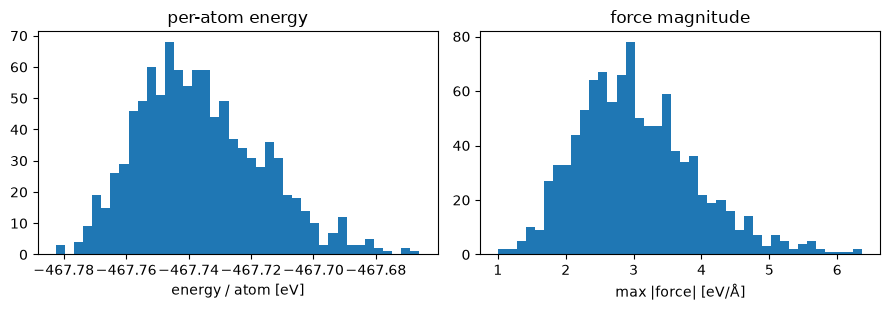

In [11]:
train = splits["ethanol"]["train"]
epa = np.array([s["energy"] / len(s["atomic_numbers"]) for s in train])
fmax = np.array([np.abs(s["forces"]).max() for s in train])

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].hist(epa, bins=40); ax[0].set(xlabel="energy / atom [eV]", title="per-atom energy")
ax[1].hist(fmax, bins=40); ax[1].set(xlabel="max |force| [eV/Å]", title="force magnitude")
plt.tight_layout()

A single conformation, coloured by element:

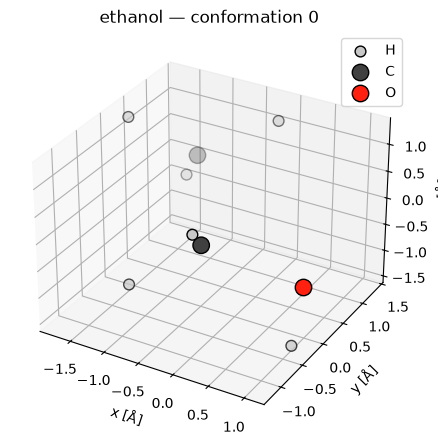

In [12]:
_ELEM = {1: ("H", "#c8c8c8", 60), 6: ("C", "#404040", 140),
         7: ("N", "#3050f8", 140), 8: ("O", "#ff2010", 140)}

s = train[0]
fig = plt.figure(figsize=(4.5, 4.5))
ax = fig.add_subplot(111, projection="3d")
for z in np.unique(s["atomic_numbers"]):
    mask = s["atomic_numbers"] == z
    sym, color, size = _ELEM[int(z)]
    ax.scatter(*s["pos"][mask].T, c=color, s=size, edgecolors="k", label=sym)
ax.set(title="ethanol — conformation 0", xlabel="x [Å]", ylabel="y [Å]", zlabel="z [Å]")
ax.legend()
plt.tight_layout()

## 6. From structure dicts to a training `DataLoader`

Pass `cutoff=` and `load_dataset` wraps each split in an `AtomicDataset`, which
builds the neighbour-list graph (`AtomicGraph`) for every structure on first
access. That's the object every `xnns` model consumes.

In [13]:
ds = load_dataset("rmd17", molecule="ethanol", cutoff=5.0)
train_ds = ds["train"]
print(type(train_ds).__name__, "| len:", len(train_ds))

g = train_ds[0]
print(f"graph 0: {g.num_nodes} atoms, {g.num_edges} edges, cell={g.cell}")

rmd17:ethanol train:   0%|          | 0/1000 [00:00<?, ? struct/s]

rmd17:ethanol test:   0%|          | 0/1000 [00:00<?, ? struct/s]

AtomicDataset | len: 1000
graph 0: 9 atoms, 72 edges, cell=None


Batch several graphs into one with xnns' `collate`. A standard PyTorch `DataLoader`
handles shuffling and batching (`batch_size=1` effectively disables batching).

In [14]:
from torch.utils.data import DataLoader

from xnns.common.data import collate

loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate)
batch = next(iter(loader))
print(f"batched graph: {batch.num_graphs} structures, {batch.num_nodes} atoms")
print(f"  energy: {tuple(batch.energy.shape)}   forces: {tuple(batch.forces.shape)}")
print(f"  batch vector maps each atom -> its structure: {batch.batch[:12].tolist()} ...")

batched graph: 8 structures, 72 atoms
  energy: (8,)   forces: (72, 3)
  batch vector maps each atom -> its structure: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1] ...


This `loader` is exactly what you'd hand to an xnns `Trainer`. See the per-model
`*_train_test.ipynb` notebooks for the full training loop.

## 7. A second built-in dataset: molecular dimers (`lode_dimers`)

The same one-liner pulls a very different dataset. **`lode_dimers`** is the
Materials Cloud set behind the LODE non-bonded-interactions work
([10.24435/materialscloud:23-99](https://doi.org/10.24435/materialscloud:23-99)):
biomolecular sidechain **dimers** with DFT energies and forces. Each pair is
tagged by the polarity of its two fragments: `CC` (charged–charged), `CP`
(charged–polar), `PP` (polar–polar), plus apolar variants. Every dimer is
scanned over a range of separations, making it a natural testbed for
**long-range** interactions.

Pick a subset with `subset=`, filter the biomolecular dimers by class with
`label=`, and attach each frame's metadata with `return_info=True`.

> **Heads-up:** the `bio` subset (`bio_dimers.xyz`) is ~66 MB; the first call
> downloads it (cached thereafter). Reading extxyz needs the `ase` extra.

In [15]:
cc = load_dataset("lode_dimers", subset="bio", label="CC",
                  split="all", return_info=True)
print(f"charged-charged (CC) dimers: {len(cc)}")

s = cc[0]
print("structure keys:", sorted(s))
print("n_atoms:", len(s["atomic_numbers"]),
      "| box:", f'{s["cell"][0, 0]:.0f} Å (large --> effectively isolated)')
meta = ("label", "dimer_id", "distance", "energyA", "energyB", "chargeA", "chargeB")
print("info:", {k: s["info"][k] for k in meta})

lode_dimers:bio [CC]:   0%|          | 0/2392 [00:00<?, ? struct/s]

charged-charged (CC) dimers: 2392
structure keys: ['atomic_numbers', 'cell', 'energy', 'forces', 'info', 'pbc', 'pos']
n_atoms: 23 | box: 30 Å (large --> effectively isolated)
info: {'label': 'CC', 'dimer_id': np.int64(0), 'distance': np.float64(6.630174209406314), 'energyA': np.float64(-7741.80993019298), 'energyB': np.float64(-6221.39955938734), 'chargeA': np.int64(1), 'chargeB': np.int64(-1)}


### Binding-energy curves

`return_info=True` attaches each frame's metadata, including the
isolated-monomer energies `energyA` / `energyB`. The **binding energy** 
$E_{AB} - E_A - E_B$ plotted against `distance` traces the attractive tail a long-range
model must capture which would be the steepest for the charged–charged pairs.

total biomolecular dimer frames: 29783


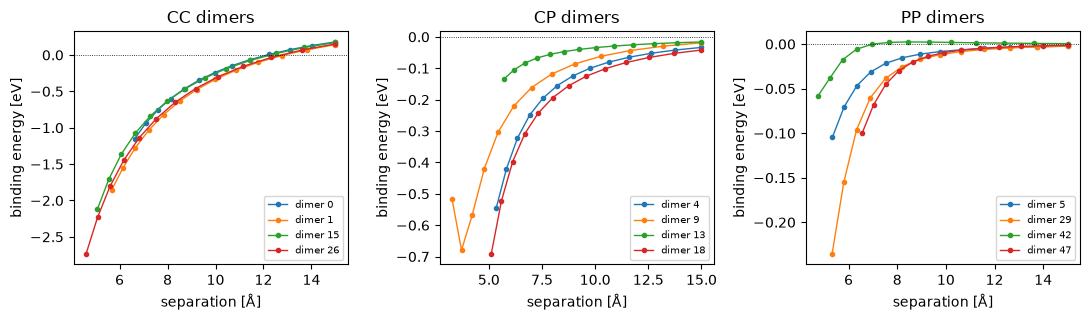

In [16]:
from collections import defaultdict

# read the biomolecular dimers once, with per-frame metadata
bio = load_dataset("lode_dimers", subset="bio", split="all",
                   return_info=True, quiet=True)
print(f"total biomolecular dimer frames: {len(bio)}")

curves = {c: defaultdict(list) for c in ("CC", "CP", "PP")}
for s in bio:
    i = s["info"]
    if i["label"] in curves:
        binding = s["energy"] - i["energyA"] - i["energyB"]
        curves[i["label"]][i["dimer_id"]].append((i["distance"], binding))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
for ax, cls in zip(axes, ("CC", "CP", "PP")):
    for did in sorted(curves[cls])[:4]:
        d, be = np.array(sorted(curves[cls][did])).T
        ax.plot(d, be, "o-", ms=3, lw=1, label=f"dimer {did}")
    ax.axhline(0, color="k", lw=0.6, ls=":")
    ax.set(title=f"{cls} dimers", xlabel="separation [Å]",
           ylabel="binding energy [eV]")
    ax.legend(fontsize=7)
plt.tight_layout()

Just like rMD17, add `cutoff=` for a ready-to-train `AtomicDataset`. Unlike
rMD17 these frames are **periodic** (a large cubic box), so the graphs carry a
`cell` and `pbc`:

In [17]:
cc_ds = load_dataset("lode_dimers", subset="bio", label="CC", cutoff=5.0)["all"]
g = cc_ds[0]
print(f"{len(cc_ds)} CC dimer graphs")
print(f"graph 0: {g.num_nodes} atoms, {g.num_edges} edges, "
      f"periodic={bool(g.pbc.all())}")

lode_dimers:bio [CC]:   0%|          | 0/2392 [00:00<?, ? struct/s]

2392 CC dimer graphs
graph 0: 23 atoms, 294 edges, periodic=True


Other subsets need no `label`: `monomers`, the point-charge toy systems
`point_charges_coulomb` (pure $1/r$) and `point_charges_dispersion` (pure
$1/r^6$), and `xenon` (Xe dimers & trimers). For example:

In [18]:
xe = load_dataset("lode_dimers", subset="xenon", split="all")
sizes = sorted(set(len(s["atomic_numbers"]) for s in xe))
print(f"xenon subset: {len(xe)} structures; sizes = {sizes} atoms (dimers & trimers)")

lode_dimers:xenon:   0%|          | 0/100 [00:00<?, ? struct/s]

xenon subset: 100 structures; sizes = [2, 3] atoms (dimers & trimers)


## 8. Registering your own dataset

The hub is extensible: subclass `DatasetBuilder`, implement `load(...)` to return
`{split: [structure_dict, ...]}` (or a single list), and call
`register_dataset(...)`. It's then reachable through the same `load_dataset()`
entry point.

Here's a tiny in-memory example (a stretched H–H dimer) so you can see the
whole contract without a download:

In [19]:
from xnns.common.data.hub import DatasetBuilder, register_dataset


class ToyDimer(DatasetBuilder):
    """A two-atom H2 dimer scanned over a few bond lengths (no download)."""

    name = "toy_dimer"
    description = "H2 dimer bond-length scan (in-memory demo)."

    def load(self, *, split=None, cache_dir, n=5, **kwargs):
        structures = []
        for d in np.linspace(0.5, 1.5, n):
            structures.append({
                "pos": np.array([[0.0, 0.0, 0.0], [0.0, 0.0, d]]),
                "atomic_numbers": np.array([1, 1]),
                "energy": float((d - 0.74) ** 2),   # toy harmonic well at r_eq
            })
        splits = {"train": structures}
        return splits if split is None else splits[split]


register_dataset(ToyDimer())
list_datasets()

['ani1', 'argon_md', 'lode_dimers', 'rmd17', 'toy_dimer']

In [20]:
toy = load_dataset("toy_dimer", n=3)
for s in toy["train"]:
    print(f"bond = {s['pos'][1, 2]:.2f} Å   energy = {s['energy']:.4f}")

# and it composes with cutoff= just like the built-ins:
toy_ds = load_dataset("toy_dimer", n=3, cutoff=2.0)["train"]
print("\nAtomicDataset:", len(toy_ds), "graphs;", toy_ds[0].num_nodes, "atoms each")

bond = 0.50 Å   energy = 0.0576
bond = 1.00 Å   energy = 0.0676
bond = 1.50 Å   energy = 0.5776

AtomicDataset: 3 graphs; 2 atoms each


## Summary

- **`load_dataset(name, ...)`**: download + preprocess in one call; returns
  structure-dict lists, or `AtomicDataset`s when you pass `cutoff=`.
- **`list_datasets()`**: what's registered.
- Data caches under **`datasets/<name>/`** (override via `cache_dir=` or
  `XNNS_DATASETS`); downloads are MD5-verified and reused.
- **rMD17** knobs: `molecule`, `split` (`train`/`test`/`all`), `fold` (1–5),
  `units` (`eV`/`kcal/mol`), `n_train`/`n_test`.
- **lode_dimers** knobs: `subset` (`bio` / `monomers` / `point_charges_coulomb`
  / `point_charges_dispersion` / `xenon`), `label` (`CC`/`CP`/`PP`/…),
  `return_info` (attach per-frame metadata), `split` (`all`).
- Add datasets by subclassing **`DatasetBuilder`** + **`register_dataset`**.


## Bundled and large datasets: `argon_md`, `bio_scan`, and `ani1`

Besides `rmd17` and `lode_dimers`, the hub also serves:

- **`argon_md`**: periodic argon configurations with energies, forces and stress, *bundled* with the repository (no download); the dataset behind the `*_argon_*` example notebooks.
- **`lode_dimers` `subset="bio_scan"`**: a curated charged/polar dimer distance scan (bundled), used by the long-range (LES / BAMBOO) examples.
- **`ani1`**: the original 20 M-conformation ANI-1 training set (Smith *et al.* 2017); one 4.8 GB archive downloaded once, with heavy-atom subset selection and conformation caps for tractable experiments.

In [21]:
# argon_md: bundled, loads offline
argon = load_dataset("argon_md")
print("argon_md:", {k: len(v) for k, v in argon.items()},
      "| keys:", sorted(argon["train"][0]))

# lode_dimers bio_scan: bundled charged/polar dimer distance scan
scan = load_dataset("lode_dimers", subset="bio_scan", split="all",
                    return_info=True)
print("bio_scan:", len(scan), "frames;",
      sorted({d['info']['label'] for d in scan}))

# ani1: the full ANI-1 training set (downloads 4.8 GB on first call);
# uncomment to fetch a small subset:
# ani = load_dataset("ani1", heavy_atoms=[2, 3], max_molecules=20,
#                    max_conformations=20)
print("registered datasets:", list_datasets())

argon_md: {'train': 200, 'test': 50} | keys: ['atomic_numbers', 'cell', 'energy', 'forces', 'pbc', 'pos', 'stress']


lode_dimers:bio_scan:   0%|          | 0/39 [00:00<?, ? struct/s]

bio_scan: 39 frames; ['CC', 'CP', 'PP']
registered datasets: ['ani1', 'argon_md', 'lode_dimers', 'rmd17', 'toy_dimer']
